# EDA: Casting Product Defect Dataset

Exploratory analysis of the casting dataset in `data/raw/casting_data/casting_data`
(train/test splits, `def_front` = defective, `ok_front` = ok).

Covers:
1. Class distribution (train/test x def_front/ok_front)
2. Sample image grids per class
3. Image size / channel checks
4. Pixel intensity distributions
5. Basic image quality checks (blur, brightness)

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import laplace

%matplotlib inline

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = Path("../data/raw/casting_data/casting_data")
SPLITS = ["train", "test"]
CLASSES = ["ok_front", "def_front"]

# Number of images sampled per (split, class) group for the more expensive
# per-image checks (pixel intensity, blur, brightness). Set to None to use
# the full dataset (slower).
SAMPLE_SIZE = 300

## 1. Build file index

In [2]:
records = []
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_DIR / split / cls
        if not folder.exists():
            continue
        for fp in folder.iterdir():
            if fp.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                records.append({"filepath": str(fp), "split": split, "label": cls})

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.head()

Total images found: 7348


,filepath,split,label
0,../data/raw/casting_data/casting_data/train/ok...,train,ok_front
1,../data/raw/casting_data/casting_data/train/ok...,train,ok_front
2,../data/raw/casting_data/casting_data/train/ok...,train,ok_front
3,../data/raw/casting_data/casting_data/train/ok...,train,ok_front
4,../data/raw/casting_data/casting_data/train/ok...,train,ok_front


## 2. Class distribution (train/test x def_front/ok_front)

In [3]:
counts = df.groupby(["split", "label"]).size().unstack(fill_value=0)
counts = counts.reindex(index=SPLITS, columns=CLASSES)
print(counts)
print()
print("Totals per split:")
print(counts.sum(axis=1))
print()
print("Totals per class:")
print(counts.sum(axis=0))

label  ok_front  def_front
split                     
train      2875       3758
test        262        453

Totals per split:
split
train    6633
test      715
dtype: int64

Totals per class:
label
ok_front     3137
def_front    4211
dtype: int64


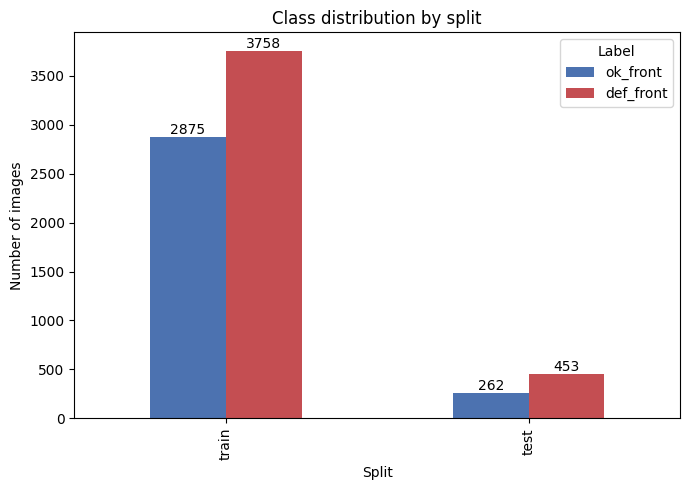

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Class distribution by split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of images")
ax.legend(title="Label")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 3. Sample image grids per class

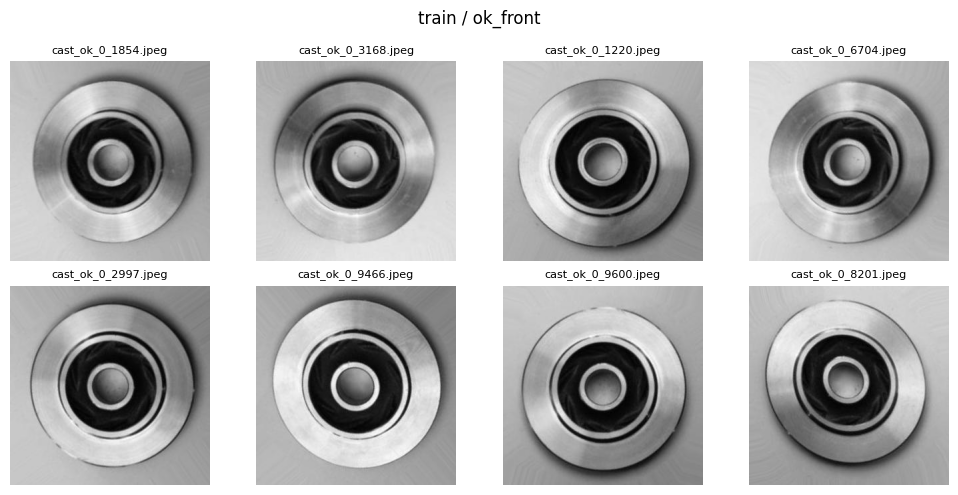

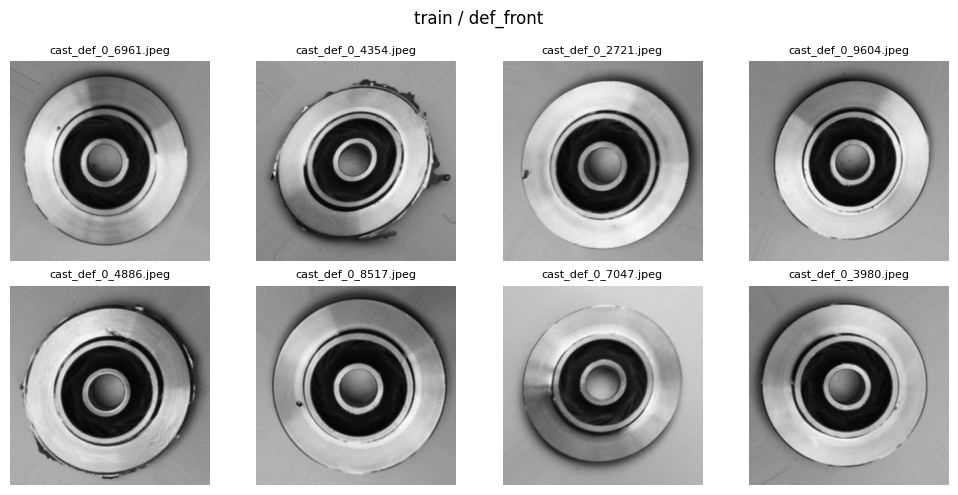

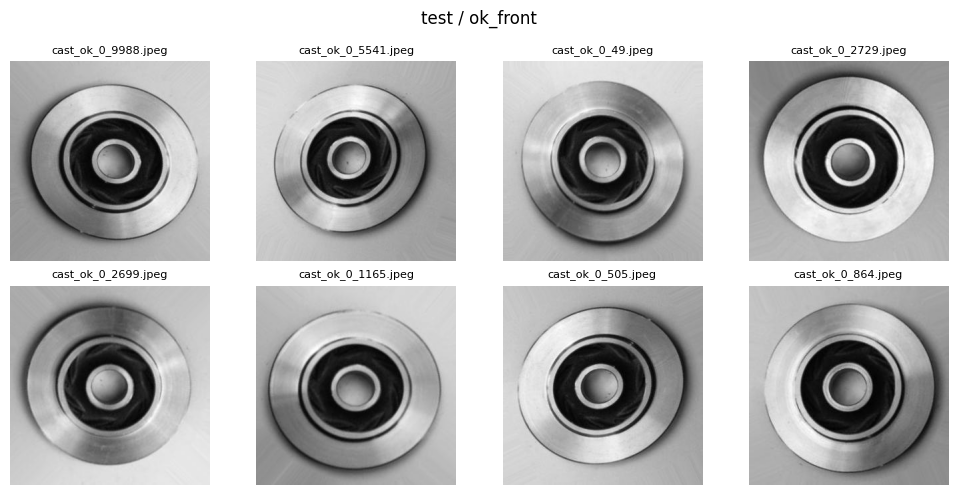

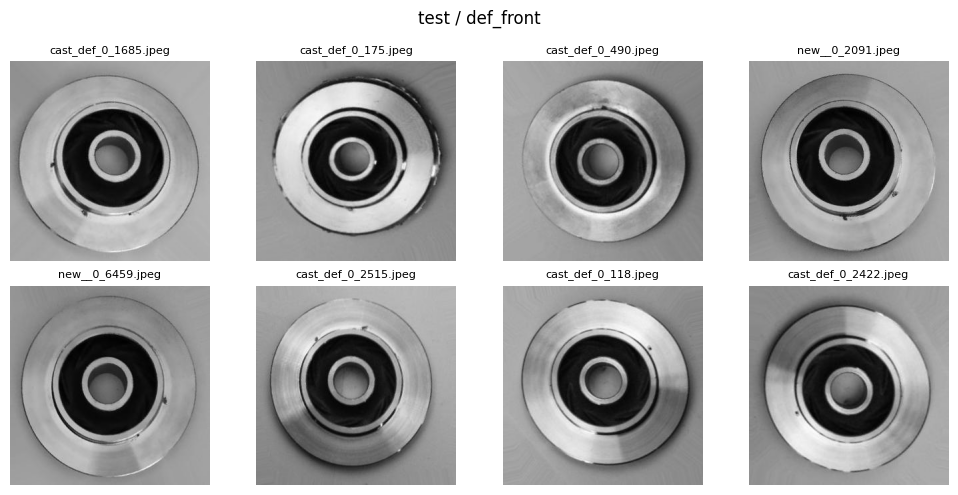

In [5]:
def show_sample_grid(split, label, n=8, cols=4):
    subset = df[(df.split == split) & (df.label == label)]
    sample = subset.sample(n=min(n, len(subset)), random_state=RANDOM_SEED)
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.array(axes).reshape(-1)
    for ax, fp in zip(axes, sample.filepath):
        img = Image.open(fp)
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
        ax.set_title(Path(fp).name, fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(f"{split} / {label}", fontsize=12)
    plt.tight_layout()
    plt.show()

for split in SPLITS:
    for cls in CLASSES:
        show_sample_grid(split, cls, n=8)

## 4. Image size / channel checks

Check every image's dimensions and color mode (fast — PIL reads only the header
for `.size`/`.mode`, not the full pixel data) and flag anything inconsistent.

In [6]:
def get_size_mode(fp):
    with Image.open(fp) as img:
        return img.size, img.mode

meta = df["filepath"].apply(get_size_mode)
df["width"] = meta.apply(lambda t: t[0][0])
df["height"] = meta.apply(lambda t: t[0][1])
df["mode"] = meta.apply(lambda t: t[1])

print("Unique (width, height):")
print(df.groupby(["width", "height"]).size())
print()
print("Unique color modes:")
print(df["mode"].value_counts())

Unique (width, height):
width  height
300    300       7348
dtype: int64

Unique color modes:
mode
RGB    7348
Name: count, dtype: int64


In [7]:
expected_size = df[["width", "height"]].mode().iloc[0]
odd_size = df[(df.width != expected_size.width) | (df.height != expected_size.height)]
print(f"Expected size: {tuple(expected_size)}")
print(f"Images with a different size: {len(odd_size)}")
if len(odd_size):
    display(odd_size[["filepath", "split", "label", "width", "height", "mode"]])

Expected size: (300, 300)
Images with a different size: 0


## 5. Pixel intensity distributions

Grayscale pixel intensity histograms per class, computed on a random sample
per (split, class) group for speed.

In [8]:
def sample_group(split, label, n=SAMPLE_SIZE):
    subset = df[(df.split == split) & (df.label == label)]
    if n is None or n >= len(subset):
        return subset
    return subset.sample(n=n, random_state=RANDOM_SEED)

def load_grayscale(fp):
    with Image.open(fp) as img:
        return np.asarray(img.convert("L"), dtype=np.float32)

samples = {
    (split, cls): sample_group(split, cls)
    for split in SPLITS
    for cls in CLASSES
}
for k, v in samples.items():
    print(k, "->", len(v), "images sampled")

('train', 'ok_front') -> 300 images sampled
('train', 'def_front') -> 300 images sampled
('test', 'ok_front') -> 262 images sampled
('test', 'def_front') -> 300 images sampled


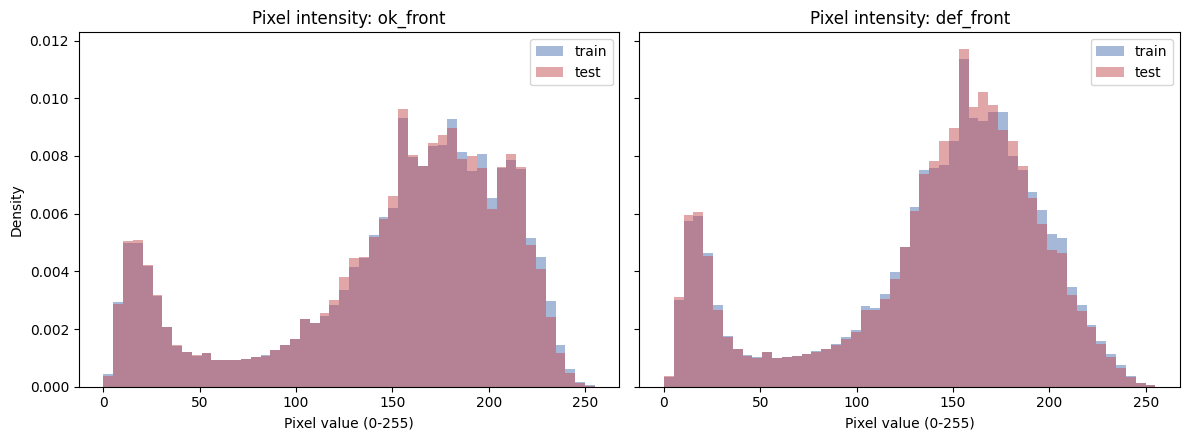

In [9]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(12, 4.5), sharey=True)
for ax, cls in zip(axes, CLASSES):
    for split, color in zip(SPLITS, ["#4C72B0", "#C44E52"]):
        pixels = np.concatenate([
            load_grayscale(fp).ravel() for fp in samples[(split, cls)].filepath
        ])
        ax.hist(pixels, bins=50, range=(0, 255), alpha=0.5, density=True,
                label=split, color=color)
    ax.set_title(f"Pixel intensity: {cls}")
    ax.set_xlabel("Pixel value (0-255)")
    ax.legend()
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

## 6. Basic image quality checks: blur and brightness

- **Brightness**: mean grayscale pixel value per image.
- **Blur**: variance of the Laplacian of the grayscale image — lower values
  indicate a blurrier (less sharp-edged) image.

In [10]:
def blur_score(gray):
    return laplace(gray).var()

def brightness_score(gray):
    return gray.mean()

quality_records = []
for (split, cls), subset in samples.items():
    for fp in subset.filepath:
        gray = load_grayscale(fp)
        quality_records.append({
            "filepath": fp,
            "split": split,
            "label": cls,
            "brightness": brightness_score(gray),
            "blur_score": blur_score(gray),
        })

quality_df = pd.DataFrame(quality_records)
quality_df.groupby(["split", "label"])[["brightness", "blur_score"]].describe().T

split                    test                   train            
label               def_front    ok_front   def_front    ok_front
brightness count   300.000000  262.000000  300.000000  300.000000
           mean    138.546295  148.879150  139.152573  149.734528
           std       5.678357    6.562513    5.700379    6.366745
           min     125.960068  132.233917  124.927246  127.007309
           25%     134.483963  141.861233  134.564331  142.903057
           50%     137.973289  151.292091  139.039940  151.678535
           75%     141.868832  153.698925  142.364979  154.381618
           max     156.275970  158.659195  155.181259  159.273849
blur_score count   300.000000  262.000000  300.000000  300.000000
           mean    238.735550  205.898209  191.572525  168.997910
           std     120.858650  100.076630   58.508156   71.884315
           min      75.773491   69.306244   71.501404   70.253952
           25%     161.737457  127.612989  147.013920   94.147181
           50%     214.946678  186.816330  184.906822  164.177132
           75%     286.667290  257.363625  230.321072  207.834465
           max    1029.518433  532.309509  376.267029  440.812012

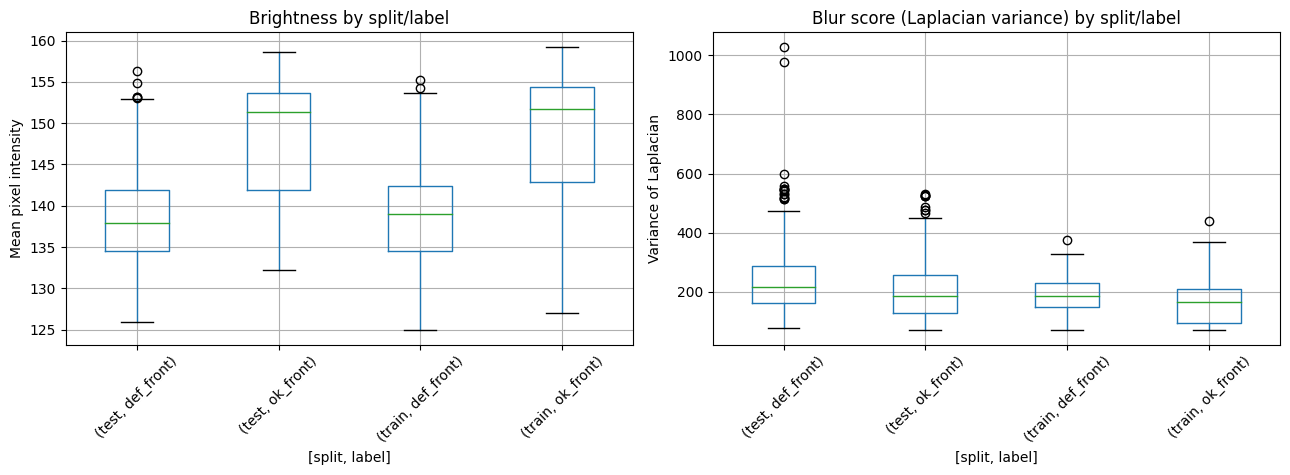

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

quality_df.boxplot(column="brightness", by=["split", "label"], ax=axes[0], rot=45)
axes[0].set_title("Brightness by split/label")
axes[0].set_ylabel("Mean pixel intensity")

quality_df.boxplot(column="blur_score", by=["split", "label"], ax=axes[1], rot=45)
axes[1].set_title("Blur score (Laplacian variance) by split/label")
axes[1].set_ylabel("Variance of Laplacian")

plt.suptitle("")
plt.tight_layout()
plt.show()

In [12]:
# Flag potential quality outliers: very blurry or very dark/bright images
# (thresholds are heuristic starting points for manual inspection, not ground truth)
blur_thresh = quality_df["blur_score"].quantile(0.05)
dark_thresh = quality_df["brightness"].quantile(0.05)
bright_thresh = quality_df["brightness"].quantile(0.95)

flagged = quality_df[
    (quality_df.blur_score <= blur_thresh)
    | (quality_df.brightness <= dark_thresh)
    | (quality_df.brightness >= bright_thresh)
]
print(f"Flagged {len(flagged)} / {len(quality_df)} sampled images as potential outliers "
      f"(bottom 5% blur score, or bottom/top 5% brightness).")
flagged.sort_values("blur_score").head(10)

Flagged 167 / 1162 sampled images as potential outliers (bottom 5% blur score, or bottom/top 5% brightness).


,filepath,split,label,brightness,blur_score
796,../data/raw/casting_data/casting_data/test/ok_...,test,ok_front,152.347549,69.306244
94,../data/raw/casting_data/casting_data/train/ok...,train,ok_front,152.913422,70.253952
49,../data/raw/casting_data/casting_data/train/ok...,train,ok_front,152.448318,70.526581
201,../data/raw/casting_data/casting_data/train/ok...,train,ok_front,152.239578,70.873558
140,../data/raw/casting_data/casting_data/train/ok...,train,ok_front,153.178207,70.879845
288,../data/raw/casting_data/casting_data/train/ok...,train,ok_front,151.986420,70.920158
372,../data/raw/casting_data/casting_data/train/de...,train,def_front,147.209839,71.501404
642,../data/raw/casting_data/casting_data/test/ok_...,test,ok_front,153.094162,71.635422
655,../data/raw/casting_data/casting_data/test/ok_...,test,ok_front,152.182404,71.660446
713,../data/raw/casting_data/casting_data/test/ok_...,test,ok_front,152.168762,71.711555


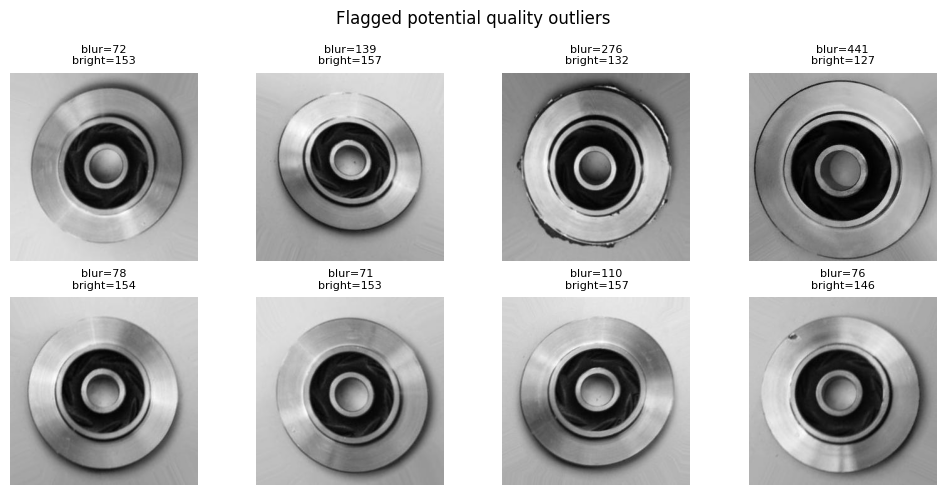

In [13]:
def show_flagged(flagged_df, n=8, cols=4):
    sample = flagged_df.sample(n=min(n, len(flagged_df)), random_state=RANDOM_SEED)
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = np.array(axes).reshape(-1)
    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row.filepath)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"blur={row.blur_score:.0f}\nbright={row.brightness:.0f}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle("Flagged potential quality outliers", fontsize=12)
    plt.tight_layout()
    plt.show()

if len(flagged):
    show_flagged(flagged)

## Summary

- Class and split counts are printed in section 1.
- All images are checked for consistent size/channels in section 4 — any
  deviations are listed explicitly rather than assumed away.
- Pixel intensity, brightness, and blur distributions (sections 5-6) give a
  quick read on whether `ok_front` and `def_front` images differ systematically
  in exposure or sharpness, and surface a shortlist of images worth a manual
  quality check before training.